**Tess Vu**

This notebook is a quick derivation from Jill's original `newpred.ipynb` that establishes some fixes, much of it is not formatted and commented yet.

In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import Point
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from shapely.geometry import box
import os

In [2]:
print(os.getcwd())

c:\Users\Tess\Desktop\UPenn\UPenn_SS26\MUSA_8010-001_Practicum\south-africa-healthcare\tess_local


In [3]:
sal = gpd.read_file("../notebooks/data/2011_census/2011_Census/ea_sal_kzn_gp.shp")

wards = gpd.read_file("../notebooks/data/2023_census/2023_census/SA_Wards2020.shp")

wards_with_pop = pd.read_csv("DAIR_data/2023_Census/wards_pop.csv", thousands = ",")

In [4]:
pd.set_option('display.float_format', '{:,.0f}'.format)
pd.set_option('display.max_columns', 100)

In [5]:
wards["WardID"]

0       10503001
1       10503002
2       10503003
3       10503004
4       10503005
          ...   
4463    34501011
4464    34501012
4465    34501013
4466    34501014
4467    34501015
Name: WardID, Length: 4468, dtype: str

In [6]:
wards_with_pop["Ward_Code"]

0       10101001
1       10101002
2       10101003
3       10101004
4       10101005
          ...   
4464    94706036
4465    94706037
4466    94706038
4467    94706039
4468       Total
Name: Ward_Code, Length: 4469, dtype: str

In [7]:
# Drop last row with "Total" in the Ward_Code.
wards_with_pop = wards_with_pop.drop(wards_with_pop.index[-1]) 

In [8]:
wards_with_pop["Ward_Code"]

0       10101001
1       10101002
2       10101003
3       10101004
4       10101005
          ...   
4463    94706035
4464    94706036
4465    94706037
4466    94706038
4467    94706039
Name: Ward_Code, Length: 4468, dtype: str

In [9]:
wards_with_pop.rename(columns = {"Ward_Code": "WardID"}, inplace = True)
wards_with_pop.rename(columns = {" Total": "Total"}, inplace = True)

In [10]:
wards = wards.merge(
    wards_with_pop[['WardID', 'Total']],
    on='WardID',
    how='left'
)

In [11]:
wards = wards[wards['Province'].isin(['Gauteng', 'KwaZulu-Natal'])].copy()

In [12]:
sal['population'].isna().sum()

np.int64(2084)

In [13]:
sal_with_ward = gpd.read_file("../notebooks/data/sal_w_ward_new/sal_w_ward_new.shp")

In [14]:
pd.set_option('display.float_format', '{:,.2f}'.format)

In [15]:
sal_with_ward=sal_with_ward.rename(columns={'census_war': 'WardID'})

In [16]:
sal_with_ward

,SP_CODE,SP_NAME,MP_CODE,MP_NAME,MN_MDB_C,MN_CODE,MN_NAME,MN_TYPE,DC_MDB_C,DC_MN_C,DC_NAME,PR_MDB_C,PR_CODE,PR_NAME,EA_GTYPE,ALBERS_ARE,MD_CODE,MD_NAME,Shape_Leng,SAL_CODE,EA_TYPE,F4_class,EA_area_km,num_houses,F4_class_2,num_build,EA_CODE_1,old_EA_TYP,smallplace,url,Black_Afri,White,Coloured,Indian_or,Other,population,F0_4,F5_9,F10_14,F15_19,F20_24,F25_29,F30_34,F35_39,F40_44,F45_49,F50_54,F55_59,F60_64,F65_69,F70_74,F75_79,F80_84,F85_,Shape_Le_1,Shape_Area,sal_pop_de,sal2011_po,OBJECTID_1,EA_CODE,WardID,AREA,PERCENTAGE,OBJECTID_2,EA_CODE_12,OBJECTID_3,FREQUENCY,EA_CODE_13,MAX_AREA,geometry
0,"503,001,001.00",KwaMaqikizane SP,"503,001.00",KwaMaqikizane,KZN213,503.00,Umzumbe,CATB,DC21,521.00,Ugu,KZN,5.00,KwaZulu-Natal,Traditional,6.06,0.00,None,0.13,"5,030,083.00",Traditional residential,Non_Wealthy,"1,506.86",131.00,Non_Wealthy,131.00,50310272,Traditional residential,5030083,https://census2011.adrianfrith.com/place/5030083,558,0,0,1,0,559,79,84,72,79,42,26,23,22,20,27,23,14,13,10,9,4,6,2,"13,216.46","6,072,531.07",0.00,559.00,584,"50,310,272.00",52103007,"6,059,185.93",99.78,272,"50,310,272.00","28,217.00",3,"50,310,272.00","6,059,185.93","POLYGON ((822771.595 6638453.565, 822700.341 6..."
1,"503,001,001.00",KwaMaqikizane SP,"503,001.00",KwaMaqikizane,KZN213,503.00,Umzumbe,CATB,DC21,521.00,Ugu,KZN,5.00,KwaZulu-Natal,Traditional,3.89,0.00,None,0.10,"5,030,157.00",Traditional residential,Non_Wealthy,"1,275.43",167.00,Non_Wealthy,167.00,50310271,Traditional residential,5030157,https://census2011.adrianfrith.com/place/5030157,713,0,0,0,0,713,101,104,104,84,51,41,19,26,28,30,25,21,33,19,8,7,3,3,"10,358.06","3,900,818.81",0.00,713.00,580,"50,310,271.00",52103007,"3,506,975.95",89.90,271,"50,310,271.00","28,623.00",4,"50,310,271.00","3,506,975.95","POLYGON ((819493.415 6637587.97, 819492.48 663..."
2,"503,002,001.00",Mthwalume SP,"503,002.00",Mthwalume,KZN213,503.00,Umzumbe,CATB,DC21,521.00,Ugu,KZN,5.00,KwaZulu-Natal,Traditional,1.92,0.00,None,0.06,"5,030,040.00",Traditional residential,Non_Wealthy,"1,121.24",135.00,Non_Wealthy,135.00,50310262,Traditional residential,5030040,https://census2011.adrianfrith.com/place/5030040,443,0,0,0,0,443,71,60,48,49,40,23,22,26,12,17,17,25,10,4,5,4,6,3,"6,136.83","1,926,623.39",0.00,443.00,562,"50,310,262.00",52103007,"1,911,598.77",99.22,262,"50,310,262.00","28,431.00",3,"50,310,262.00","1,911,598.77","POLYGON ((824803.527 6636980.442, 824776.674 6..."
3,"503,002,001.00",Mthwalume SP,"503,002.00",Mthwalume,KZN213,503.00,Umzumbe,CATB,DC21,521.00,Ugu,KZN,5.00,KwaZulu-Natal,Traditional,1.70,0.00,None,0.06,"5,030,172.00",Traditional residential,Non_Wealthy,"1,161.38",154.00,Non_Wealthy,153.00,50310266,Traditional residential,5030172,https://census2011.adrianfrith.com/place/5030172,740,0,1,1,1,743,112,97,97,91,64,50,27,28,30,31,21,28,22,15,7,8,10,4,"6,002.79","1,706,669.43",0.00,743.00,570,"50,310,266.00",52103007,"1,687,526.67",98.88,266,"50,310,266.00","28,241.00",2,"50,310,266.00","1,687,526.67","POLYGON ((823795.835 6638400.097, 823789.875 6..."
4,"503,003,001.00",Ngomakazi SP,"503,003.00",Ngomakazi,KZN213,503.00,Umzumbe,CATB,DC21,521.00,Ugu,KZN,5.00,KwaZulu-Natal,Traditional,4.05,0.00,None,0.10,"5,030,022.00",Traditional residential,Non_Wealthy,931.82,92.00,Non_Wealthy,92.00,50310265,Traditional residential,5030022,https://census2011.adrianfrith.com/place/5030022,339,0,0,0,0,339,55,39,40,47,19,17,18,9,12,19,14,8,11,12,1,4,6,1,"10,452.00","4,054,490.58",0.00,339.00,567,"50,310,265.00",52103006,"2,657,911.10",65.55,265,"50,310,265.00","28,287.00",2,"50,310,265.00","2,657,911.10","POLYGON ((823864.034 6636374.407, 823832.145 6..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39172,"599,116,038.00",Mariannhill,"599,116.00",Pinetown,ETH,599.00,Ethekwini,METRO,ETH,599.

In [17]:
sal_with_ward = sal_with_ward.merge(
    wards[['WardID', 'Total']],
    on='WardID',
    how='left'
)

In [18]:
sal_with_ward

,SP_CODE,SP_NAME,MP_CODE,MP_NAME,MN_MDB_C,MN_CODE,MN_NAME,MN_TYPE,DC_MDB_C,DC_MN_C,DC_NAME,PR_MDB_C,PR_CODE,PR_NAME,EA_GTYPE,ALBERS_ARE,MD_CODE,MD_NAME,Shape_Leng,SAL_CODE,EA_TYPE,F4_class,EA_area_km,num_houses,F4_class_2,num_build,EA_CODE_1,old_EA_TYP,smallplace,url,Black_Afri,White,Coloured,Indian_or,Other,population,F0_4,F5_9,F10_14,F15_19,F20_24,F25_29,F30_34,F35_39,F40_44,F45_49,F50_54,F55_59,F60_64,F65_69,F70_74,F75_79,F80_84,F85_,Shape_Le_1,Shape_Area,sal_pop_de,sal2011_po,OBJECTID_1,EA_CODE,WardID,AREA,PERCENTAGE,OBJECTID_2,EA_CODE_12,OBJECTID_3,FREQUENCY,EA_CODE_13,MAX_AREA,geometry,Total
0,"503,001,001.00",KwaMaqikizane SP,"503,001.00",KwaMaqikizane,KZN213,503.00,Umzumbe,CATB,DC21,521.00,Ugu,KZN,5.00,KwaZulu-Natal,Traditional,6.06,0.00,None,0.13,"5,030,083.00",Traditional residential,Non_Wealthy,"1,506.86",131.00,Non_Wealthy,131.00,50310272,Traditional residential,5030083,https://census2011.adrianfrith.com/place/5030083,558,0,0,1,0,559,79,84,72,79,42,26,23,22,20,27,23,14,13,10,9,4,6,2,"13,216.46","6,072,531.07",0.00,559.00,584,"50,310,272.00",52103007,"6,059,185.93",99.78,272,"50,310,272.00","28,217.00",3,"50,310,272.00","6,059,185.93","POLYGON ((822771.595 6638453.565, 822700.341 6...",5887
1,"503,001,001.00",KwaMaqikizane SP,"503,001.00",KwaMaqikizane,KZN213,503.00,Umzumbe,CATB,DC21,521.00,Ugu,KZN,5.00,KwaZulu-Natal,Traditional,3.89,0.00,None,0.10,"5,030,157.00",Traditional residential,Non_Wealthy,"1,275.43",167.00,Non_Wealthy,167.00,50310271,Traditional residential,5030157,https://census2011.adrianfrith.com/place/5030157,713,0,0,0,0,713,101,104,104,84,51,41,19,26,28,30,25,21,33,19,8,7,3,3,"10,358.06","3,900,818.81",0.00,713.00,580,"50,310,271.00",52103007,"3,506,975.95",89.90,271,"50,310,271.00","28,623.00",4,"50,310,271.00","3,506,975.95","POLYGON ((819493.415 6637587.97, 819492.48 663...",5887
2,"503,002,001.00",Mthwalume SP,"503,002.00",Mthwalume,KZN213,503.00,Umzumbe,CATB,DC21,521.00,Ugu,KZN,5.00,KwaZulu-Natal,Traditional,1.92,0.00,None,0.06,"5,030,040.00",Traditional residential,Non_Wealthy,"1,121.24",135.00,Non_Wealthy,135.00,50310262,Traditional residential,5030040,https://census2011.adrianfrith.com/place/5030040,443,0,0,0,0,443,71,60,48,49,40,23,22,26,12,17,17,25,10,4,5,4,6,3,"6,136.83","1,926,623.39",0.00,443.00,562,"50,310,262.00",52103007,"1,911,598.77",99.22,262,"50,310,262.00","28,431.00",3,"50,310,262.00","1,911,598.77","POLYGON ((824803.527 6636980.442, 824776.674 6...",5887
3,"503,002,001.00",Mthwalume SP,"503,002.00",Mthwalume,KZN213,503.00,Umzumbe,CATB,DC21,521.00,Ugu,KZN,5.00,KwaZulu-Natal,Traditional,1.70,0.00,None,0.06,"5,030,172.00",Traditional residential,Non_Wealthy,"1,161.38",154.00,Non_Wealthy,153.00,50310266,Traditional residential,5030172,https://census2011.adrianfrith.com/place/5030172,740,0,1,1,1,743,112,97,97,91,64,50,27,28,30,31,21,28,22,15,7,8,10,4,"6,002.79","1,706,669.43",0.00,743.00,570,"50,310,266.00",52103007,"1,687,526.67",98.88,266,"50,310,266.00","28,241.00",2,"50,310,266.00","1,687,526.67","POLYGON ((823795.835 6638400.097, 823789.875 6...",5887
4,"503,003,001.00",Ngomakazi SP,"503,003.00",Ngomakazi,KZN213,503.00,Umzumbe,CATB,DC21,521.00,Ugu,KZN,5.00,KwaZulu-Natal,Traditional,4.05,0.00,None,0.10,"5,030,022.00",Traditional residential,Non_Wealthy,931.82,92.00,Non_Wealthy,92.00,50310265,Traditional residential,5030022,https://census2011.adrianfrith.com/place/5030022,339,0,0,0,0,339,55,39,40,47,19,17,18,9,12,19,14,8,11,12,1,4,6,1,"10,452.00","4,054,490.58",0.00,339.00,567,"50,310,265.00",52103006,"2,657,911.10",65.55,265,"50,310,265.00","28,287.00",2,"50,310,265.00","2,657,911.10","POLYGON ((823864.034 6636374.407, 823832.145 6...",7902
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39172,"599,116,038.00",Mariannhill,"599,116.00",Pinetown,

In [19]:
# SELECT COLUMNS AND DEDUPLICATE BY WARD OVERLAP
# Sort by PERCENTAGE descending so the SAL-ward pair with the
# largest area overlap is kept during deduplication.
sal_wards = sal_with_ward[
    ["WardID", "EA_CODE", "sal2011_po", "Total", "EA_GTYPE", "EA_TYPE",
     "F4_class", "num_houses", "Black_Afri", "White", "Coloured",
     "Indian_or", "Other", "PERCENTAGE", "Shape_Area"]
].copy()

# Assign each SAL to the ward with the largest geometric overlap.
sal_wards = (
    sal_wards.sort_values("PERCENTAGE", ascending = False)
    .drop_duplicates(subset = "EA_CODE", keep = "first")
    .reset_index(drop = True)
)

print(f"SAL rows after dedup: {len(sal_wards)}")


SAL rows after dedup: 38380


In [20]:
sal_wards = sal_wards.rename(columns = {
    "sal2011_po": "sal2011_pop",
    "Total": "ward2023_pop",
    "F4_class": "econ_status",
    "num_houses": "houses2011"
})

# Compute area_km2 from the SAL polygon area (Shape_Area is in CRS units squared).
# sal_w_ward_new.shp is in EPSG:32735 (UTM zone 35S), so Shape_Area is in m².
sal_wards["area_km2"] = sal_wards["Shape_Area"] / 1e6

# Drop helper columns no longer needed.
sal_wards = sal_wards.drop(columns = ["PERCENTAGE", "Shape_Area"])


In [21]:
sal_wards['EA_TYPE'] = sal_wards['EA_TYPE'].str.replace(r'_\*$', '', regex=True)
sal_wards['EA_TYPE'] = sal_wards['EA_TYPE'].str.replace(
    'Smallholdings', 'Small holdings'
)

In [22]:
# ZERO-POPULATION IMPUTATION
# For SALs with 2011 pop of 0 but nonzero dwelling count, impute
# using Stats SA 2022 Census average household size of 3.3.
# SALs with both pop = 0 and houses = 0 remain at zero (truly vacant).
HH_SIZE = 3.3

zero_pop_mask = sal_wards["sal2011_pop"] == 0
has_houses_mask = sal_wards["houses2011"] > 0
impute_mask = zero_pop_mask & has_houses_mask

sal_wards.loc[impute_mask, "sal2011_pop"] = (
    sal_wards.loc[impute_mask, "houses2011"] * HH_SIZE
)

imputed_count = impute_mask.sum()
remaining_zero = (sal_wards["sal2011_pop"] == 0).sum()
print(f"Imputed {imputed_count} SALs with pop = 0 but houses > 0.")
print(f"Remaining zero-pop SALs (truly vacant): {remaining_zero}")

# DENSITY COLUMNS (for EDA, not used in step-down weight).
sal_wards["sal_dense"] = (
    sal_wards["sal2011_pop"].astype(float) /
    sal_wards["area_km2"].astype(float)
)
sal_wards["log_density"] = np.log1p(sal_wards["sal_dense"])


Imputed 1190 SALs with pop = 0 but houses > 0.
Remaining zero-pop SALs (truly vacant): 1270


In [23]:
sal_wards

,WardID,EA_CODE,sal2011_pop,ward2023_pop,EA_GTYPE,EA_TYPE,econ_status,houses2011,Black_Afri,White,Coloured,Indian_or,Other,area_km2,sal_dense,log_density
0,74202006,"76,110,178.00",593.00,13560,Urban,Township,Non_Wealthy,216.00,592,0,1,0,0,0.07,"8,903.56",9.09
1,79800001,"79,810,104.00",527.00,54031,Urban,Formal residential,Wealthy,184.00,518,0,8,1,0,0.09,"5,652.65",8.64
2,59500005,"59,913,334.00","1,122.00",32703,Traditional,Traditional residential,Non_Wealthy,153.00,1120,1,1,0,0,1.04,"1,078.78",6.98
3,79800002,"79,810,172.00",716.00,44142,Urban,Township,Non_Wealthy,188.00,706,0,6,0,4,0.13,"5,727.63",8.65
4,79800078,"79,816,188.00",850.00,60533,Urban,Informal residential,Non_Wealthy,460.00,844,0,0,0,6,0.02,"55,317.98",10.92
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38375,52606017,"58,110,074.00",154.00,9549,Traditional,Vacant,Non_Residential,95.00,154,0,0,0,0,132.76,1.16,0.77
38376,79700101,"79,710,170.00",597.00,25013,Urban,Township,Non_Wealthy,100.00,594,1,0,0,2,0.72,827.33,6.72
38377,52702013,"58,310,239.00",208.00,11043,Traditional,Vacant,Non_Residential,63.00,203,0,0,5,0,28.65,7.26,2.11
38378,52801005,"58,710,009.00",4.00,11116,Traditional,Vacant,Non_Residential,1.00,0,0,0,0,0,8.72,0.46,0.38


In [24]:
sal_wards['log_density'].describe()

count   38,380.00
mean         7.41
std          2.48
min          0.00
25%          6.31
50%          8.11
75%          9.14
max         13.40
Name: log_density, dtype: float64

In [25]:
# Coerce to numeric in case of string remnants from CSV reads.
sal_wards["ward2023_pop"] = pd.to_numeric(sal_wards["ward2023_pop"], errors = "coerce")
sal_wards["sal2011_pop"] = pd.to_numeric(sal_wards["sal2011_pop"], errors = "coerce")

In [26]:
# VALIDATION: Confirm no duplicate EA_CODEs remain.
dupes = sal_wards[sal_wards.duplicated(subset = "EA_CODE", keep = False)]
print(f"Duplicate EA_CODEs remaining: {len(dupes)}")

assert len(dupes) == 0, "Unexpected duplicates after dedup step."

Duplicate EA_CODEs remaining: 0


In [27]:
# PROPORTIONAL STEP-DOWN WEIGHT
# Compute each SAL's share of its parent ward's 2011 population.
# This is the standard step-down method (Luo & Wang 2003).
ward2011_sum = sal_wards.groupby("WardID", as_index = False)["sal2011_pop"].sum()
ward2011_sum = ward2011_sum.rename(columns = {"sal2011_pop": "ward2011_sum"})

sal_wards = sal_wards.merge(
    ward2011_sum,
    on = "WardID",
    how = "left"
)

sal_wards["share2011"] = sal_wards["sal2011_pop"] / sal_wards["ward2011_sum"]

# Shares should sum to 1 within each ward (pycnophylactic constraint).
ward_share_sums = sal_wards.groupby("WardID")["share2011"].sum()
print(f"Ward share sums — min: {ward_share_sums.min():.6f}, max: {ward_share_sums.max():.6f}")


Ward share sums — min: 1.000000, max: 1.000000


In [28]:
sal_wards['share2011'].describe()

count   38,380.00
mean         0.04
std          0.04
min          0.00
25%          0.02
50%          0.02
75%          0.05
max          0.60
Name: share2011, dtype: float64

In [63]:
# Note: log_density is retained for EDA but NOT used in the step-down weight.
# Using share2011 alone avoids double-counting the 2011 population signal
# (share2011 and log_density are both derived from sal2011_pop).


In [65]:
# sal_wards['gweight'].describe()

In [29]:
# STEP-DOWN WEIGHT = share2011 (proportional allocation).
# No density re-weighting, avoids circularity with 2011 pop.
sal_wards["dasym_weight"] = sal_wards["share2011"]

In [30]:
sal_wards['dasym_weight'].describe()

count   38,380.00
mean         0.04
std          0.04
min          0.00
25%          0.02
50%          0.02
75%          0.05
max          0.60
Name: dasym_weight, dtype: float64

In [31]:
# ESTIMATE 2023 SAL POPULATION
# Distribute 2023 ward population to SALs using proportional weights.
sal_wards["sal2023_est"] = sal_wards["dasym_weight"] * sal_wards["ward2023_pop"]

total_est = sal_wards["sal2023_est"].sum()
print(f"Total estimated 2023 pop: {total_est:,.0f}")

Total estimated 2023 pop: 27,523,308


In [32]:
# COMPOUND ANNUAL GROWTH RATE (2011-2023, 12 years).
sal_wards["growth_rate"] = (
    (sal_wards["sal2023_est"] / sal_wards["sal2011_pop"]) ** (1 / 12)
) - 1

In [33]:
sal_wards['ward2023_pop'].describe()

count    38,380.00
mean     27,492.23
std      19,153.58
min       1,444.00
25%      11,209.00
50%      23,593.00
75%      37,831.00
max     126,728.00
Name: ward2023_pop, dtype: float64

In [34]:
sal_wards['sal2023_est'].describe()

count   38,380.00
mean       717.13
std        493.44
min          0.00
25%        373.69
50%        667.21
75%        976.86
max     13,852.18
Name: sal2023_est, dtype: float64

In [35]:
sal_wards['sal2023_est'].sum()

np.float64(27523308.0)

In [36]:
wards["ward2023_pop"] = pd.to_numeric(wards["Total"], errors = "coerce")

In [37]:
wards['ward2023_pop'].sum()

np.int64(27523308)

In [38]:
sal_wards['sal2023_est'].sum()-wards['ward2023_pop'].sum() 

np.float64(0.0)

In [39]:
sal_wards[['sal2011_pop','sal2023_est', ]].sum()

sal2011_pop   24,741,954.10
sal2023_est   27,523,308.00
dtype: float64

In [40]:
sal_wards['EA_CODE'] = sal_wards['EA_CODE'].astype('Int64')   # or str if needed

In [41]:
sal_wards

,WardID,EA_CODE,sal2011_pop,ward2023_pop,EA_GTYPE,EA_TYPE,econ_status,houses2011,Black_Afri,White,Coloured,Indian_or,Other,area_km2,sal_dense,log_density,ward2011_sum,share2011,dasym_weight,sal2023_est,growth_rate
0,74202006,76110178,593.00,13560,Urban,Township,Non_Wealthy,216.00,592,0,1,0,0,0.07,"8,903.56",9.09,"9,229.00",0.06,0.06,871.28,0.03
1,79800001,79810104,527.00,54031,Urban,Formal residential,Wealthy,184.00,518,0,8,1,0,0.09,"5,652.65",8.64,"33,914.30",0.02,0.02,839.60,0.04
2,59500005,59913334,"1,122.00",32703,Traditional,Traditional residential,Non_Wealthy,153.00,1120,1,1,0,0,1.04,"1,078.78",6.98,"29,460.00",0.04,0.04,"1,245.51",0.01
3,79800002,79810172,716.00,44142,Urban,Township,Non_Wealthy,188.00,706,0,6,0,4,0.13,"5,727.63",8.65,"31,830.00",0.02,0.02,992.95,0.03
4,79800078,79816188,850.00,60533,Urban,Informal residential,Non_Wealthy,460.00,844,0,0,0,6,0.02,"55,317.98",10.92,"49,298.20",0.02,0.02,"1,043.71",0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38375,52606017,58110074,154.00,9549,Traditional,Vacant,Non_Residential,95.00,154,0,0,0,0,132.76,1.16,0.77,"7,740.20",0.02,0.02,189.99,0.02
38376,79700101,79710170,597.00,25013,Urban,Township,Non_Wealthy,100.00,594,1,0,0,2,0.72,827.33,6.72,"16,186.00",0.04,0.04,922.57,0.04
38377,52702013,58310239,208.00,11043,Traditional,Vacant,Non_Residential,63.00,203,0,0,5,0,28.65,7.26,2.11,"10,383.90",0.02,0.02,221.20,0.01
38378,52801005,58710009,4.00,11116,Traditional,Vacant,Non_Residential,1.00,0,0,0,0,0,8.72,0.46,0.38,"6,709.00",0.00,0.00,6.63,0.04


In [42]:
print(sal_wards.head().to_markdown(index=False, floatfmt=",.2f"))

|   WardID |   EA_CODE |   sal2011_pop |   ward2023_pop | EA_GTYPE    | EA_TYPE                 | econ_status   |   houses2011 |   Black_Afri |   White |   Coloured |   Indian_or |   Other |   area_km2 |   sal_dense |   log_density |   ward2011_sum |   share2011 |   dasym_weight |   sal2023_est |   growth_rate |
|---------:|----------:|--------------:|---------------:|:------------|:------------------------|:--------------|-------------:|-------------:|--------:|-----------:|------------:|--------:|-----------:|------------:|--------------:|---------------:|------------:|---------------:|--------------:|--------------:|
| 74202006 |  76110178 |        593.00 |          13560 | Urban       | Township                | Non_Wealthy   |       216.00 |          592 |       0 |          1 |           0 |       0 |       0.07 |    8,903.56 |          9.09 |       9,229.00 |        0.06 |           0.06 |        871.28 |          0.03 |
| 79800001 |  79810104 |        527.00 |          54031 | 

In [43]:
gtype_summary = sal_wards.groupby('EA_TYPE').agg(
    pop2011=('sal2011_pop','sum'),
    pop2023=('sal2023_est','sum'),
).reset_index()

gtype_summary['growth_rate_2011_2023'] = (
    ((gtype_summary['pop2023'] / gtype_summary['pop2011']) ** (1/12) - 1)*100
)

In [44]:
sal_wards['sal_dense'].describe()

count    38,380.00
mean      7,108.06
std      12,795.79
min           0.00
25%         548.80
50%       3,316.19
75%       9,339.27
max     662,594.71
Name: sal_dense, dtype: float64

In [45]:
gtype_summary

,EA_TYPE,pop2011,pop2023,growth_rate_2011_2023
0,Collective living quarters,"341,906.30","265,368.95",-2.09
1,Commercial,"354,777.50","265,369.85",-2.39
2,Farms,"465,265.70","446,194.02",-0.35
3,Formal residential,"8,070,637.50","7,590,670.46",-0.51
4,Industrial,"209,060.40","191,737.11",-0.72
5,Informal residential,"1,854,216.10","2,407,169.76",2.20
6,Parks and recreation,"22,181.70","16,585.38",-2.39
7,Small holdings,"282,146.90","305,072.38",0.65
8,Township,"7,695,373.70","9,821,066.87",2.05
9,Traditional residential,"5,170,932.20","5,928,199.96",1.15


In [87]:
#print(gtype_summary.to_markdown(index=False, floatfmt=",.2f"))

In [46]:
sal_map = sal.merge(
    sal_wards,
    on='EA_CODE',
    how='left'
)

C:\Users\Tess\AppData\Local\Temp\ipykernel_110172\999446382.py:1: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  sal_map = sal.merge(


In [47]:
sal_wards['sal2023_est'].describe()

count   38,380.00
mean       717.13
std        493.44
min          0.00
25%        373.69
50%        667.21
75%        976.86
max     13,852.18
Name: sal2023_est, dtype: float64

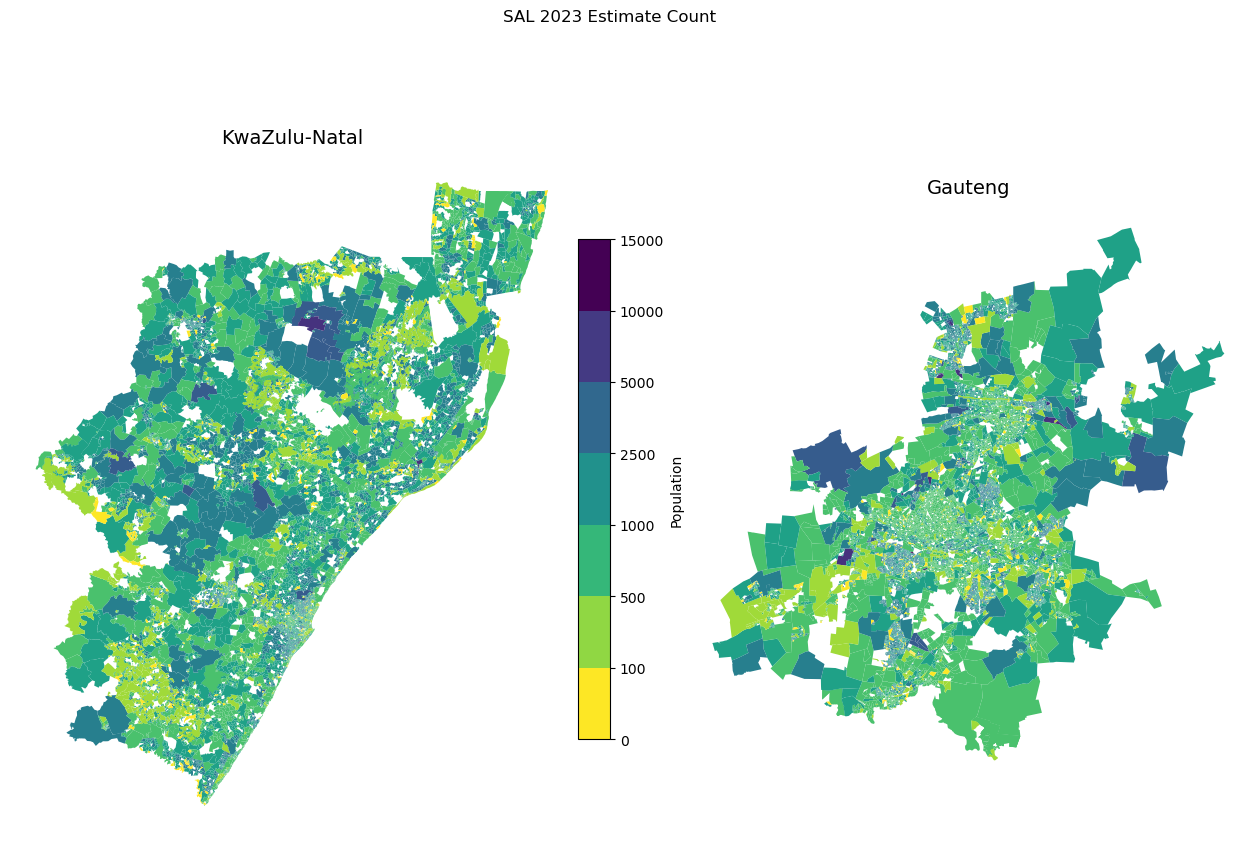

Map saved to pop2023estimate.png


In [48]:
import mapclassify
import matplotlib.pyplot as plt
import matplotlib as mpl

fig, axes = plt.subplots(1, 2, figsize=(16,10))

provinces = sal_map['PR_NAME'].unique()

# consistent bins
bin_edges = [0,100, 500,1000, 2500, 5000, 10000, 15000]

cmap = mpl.cm.viridis_r

for i, prov in enumerate(provinces):

    subset = sal_map[sal_map['PR_NAME'] == prov].copy()
    subset = subset[subset['sal2023_est'].notna()]  # drop missing

    subset.plot(
        column='sal2023_est',
        cmap=cmap,
        scheme='UserDefined',
        classification_kwds={'bins': bin_edges},
        legend=False,
        ax=axes[i]
    )

    axes[i].set_title(prov, fontsize=14)
    axes[i].axis('off')

# ---- shared colorbar (fixed mapping) ----
norm = mpl.colors.BoundaryNorm(bin_edges, ncolors=cmap.N)
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar_ax = fig.add_axes([0.48, 0.25, 0.02, 0.5])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Population")

plt.suptitle("SAL 2023 Estimate Count")

output_file = "pop2023estimate.png"
#plt.savefig(output_file, dpi=300, bbox_inches='tight')

plt.show()

print(f"Map saved to {output_file}")

In [49]:
sal_map['dense_2023']= sal_map['sal2023_est']/sal_map['area_km2']

In [50]:
sal_map['dense_2023'].describe()

count    34,781.00
mean      7,684.09
std      12,753.33
min           0.00
25%         526.40
50%       3,225.20
75%      10,889.43
max     449,414.58
Name: dense_2023, dtype: float64

In [51]:
sal_map['log_density'] = np.log1p(sal_map['dense_2023'])

In [52]:
sal_map['log_density'].describe()

count   34,781.00
mean         7.42
std          2.53
min          0.00
25%          6.27
50%          8.08
75%          9.30
max         13.02
Name: log_density, dtype: float64

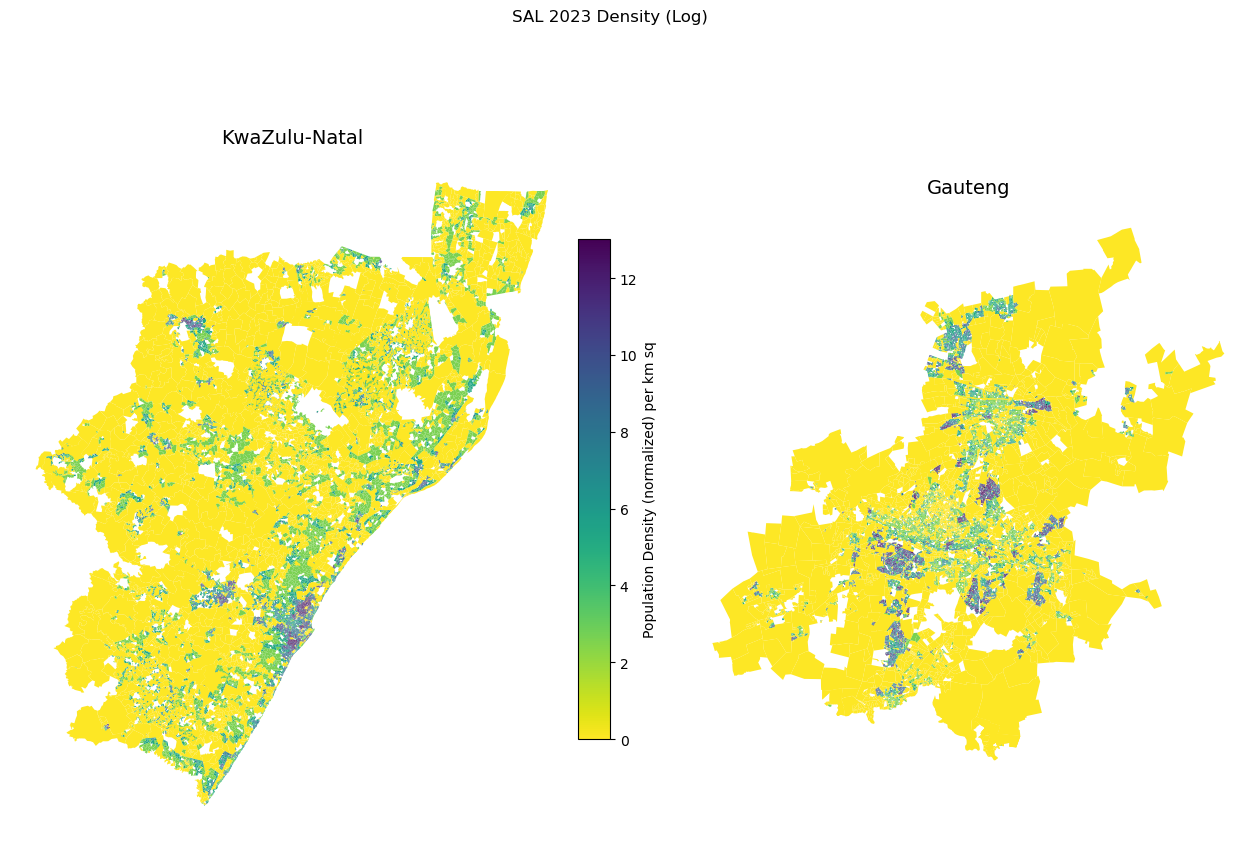

Map saved to popdensity.png


In [53]:
import mapclassify
import matplotlib.pyplot as plt
import matplotlib as mpl
fig, axes = plt.subplots(1, 2, figsize=(16,10))

provinces = sal_map['PR_NAME'].unique()

for i, prov in enumerate(provinces):
    
    subset = sal_map[sal_map['PR_NAME'] == prov].copy()
    
    # compute quintile breaks
    subset.plot(
        column='log_density',
        cmap='viridis_r',
        legend=False,
        scheme='Quantiles',
        k=6,
        ax=axes[i]
    )
        
    axes[i].set_title(prov, fontsize=14)
    axes[i].axis('off')

# 🔥 Create shared colorbar in the middle
norm = mpl.colors.Normalize(
    vmin=sal_map['log_density'].min(),
    vmax=sal_map['log_density'].max()
)
sm = mpl.cm.ScalarMappable(cmap='viridis_r', norm=norm)
sm.set_array([])

# [left, bottom, width, height] → tweak these numbers if needed
cbar_ax = fig.add_axes([0.48, 0.25, 0.02, 0.5])  

cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Population Density (normalized) per km sq")
plt.suptitle("SAL 2023 Density (Log)")
output_file = "popdensity.png"
#plt.savefig(output_file, dpi=300, bbox_inches='tight')

plt.show()

print(f"Map saved to {output_file}")

In [54]:
sal_wards.to_csv('pop_pred_final.csv', index=False)

In [55]:
sal_map = sal_map.to_crs(sal_with_ward.crs)

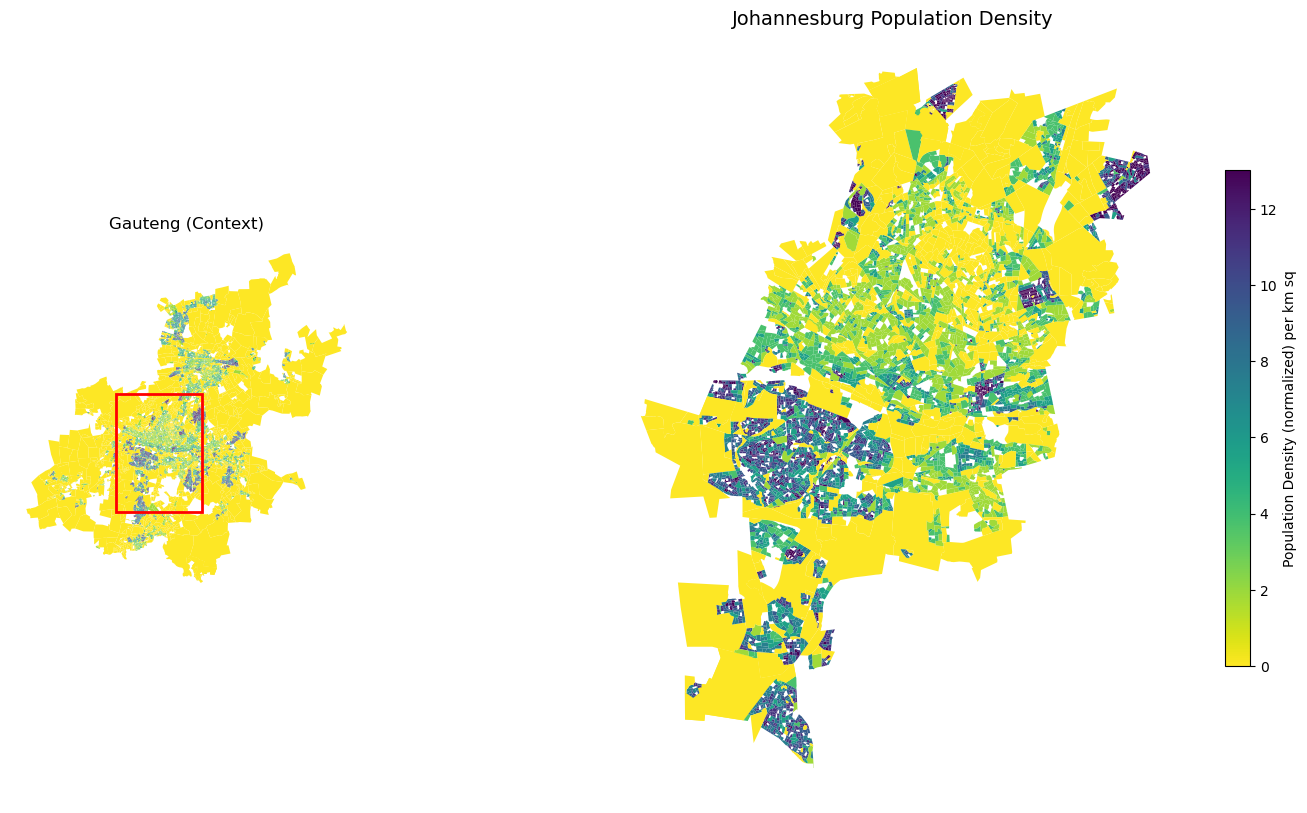

Map saved to gauteng_joburg_sidebyside_rect.png


In [56]:
import mapclassify
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Rectangle

# -------------------------
# FILTER DATA
# -------------------------
gauteng = sal_map[sal_map['PR_NAME'].str.contains("Gauteng", case=False, na=False)].copy()

jhb = gauteng[gauteng['MN_NAME'].str.contains("Johannesburg", case=False, na=False)]

# -------------------------
# FIGURE (Joburg bigger)
# -------------------------
fig, axes = plt.subplots(
    1, 2,
    figsize=(16,10),
    gridspec_kw={'width_ratios': [1, 2]}  # Joburg panel bigger
)

# -------------------------
# LEFT: GAUTENG (context)
# -------------------------
gauteng.plot(
    column='log_density',
    cmap='viridis_r',
    legend=False,
    scheme='Quantiles',
    k=8,
    ax=axes[0]
)

# Add rectangular outline for Johannesburg
xmin, ymin, xmax, ymax = jhb.total_bounds
pad_x = (xmax - xmin) * 0.02  # slight padding
pad_y = (ymax - ymin) * 0.02

rect = Rectangle(
    (xmin - pad_x, ymin - pad_y),
    (xmax - xmin) + 2*pad_x,
    (ymax - ymin) + 2*pad_y,
    linewidth=2,
    edgecolor='red',
    facecolor='none'
)
axes[0].add_patch(rect)

axes[0].set_title("Gauteng (Context)", fontsize=12)
axes[0].axis('off')

# -------------------------
# RIGHT: JOHANNESBURG (zoom)
# -------------------------
jhb.plot(
    column='log_density',
    cmap='viridis_r',
    legend=False,
    scheme='Quantiles',
    k=8,
    ax=axes[1]
)

axes[1].set_title("Johannesburg Population Density ", fontsize=14)
axes[1].axis('off')

# -------------------------
# SHARED COLORBAR
# -------------------------
norm = mpl.colors.Normalize(
    vmin=sal_map['log_density'].min(),
    vmax=sal_map['log_density'].max()
)

sm = mpl.cm.ScalarMappable(cmap='viridis_r', norm=norm)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes,
    fraction=0.02,
    pad=0.04
)
cbar.set_label("Population Density (normalized) per km sq")

# -------------------------
# SAVE
# -------------------------
output_file = "gauteng_joburg_sidebyside_rect.png"
#plt.savefig(output_file, dpi=300, bbox_inches='tight')

plt.show()
print(f"Map saved to {output_file}")

In [57]:
sal_wards['sal_dense'].describe()

count    38,380.00
mean      7,108.06
std      12,795.79
min           0.00
25%         548.80
50%       3,316.19
75%       9,339.27
max     662,594.71
Name: sal_dense, dtype: float64

In [58]:
print(sal_with_ward.crs)

EPSG:32735


In [59]:
print(sal_wards['share2011'].describe().to_markdown(index=False, floatfmt=",.2f"))

|   share2011 |
|------------:|
|   38,380.00 |
|        0.04 |
|        0.04 |
|        0.00 |
|        0.02 |
|        0.02 |
|        0.05 |
|        0.60 |


In [60]:
sal_wards[sal_wards['sal_dense'] >100000].sort_values('area_km2')

,WardID,EA_CODE,sal2011_pop,ward2023_pop,EA_GTYPE,EA_TYPE,econ_status,houses2011,Black_Afri,White,Coloured,Indian_or,Other,area_km2,sal_dense,log_density,ward2011_sum,share2011,dasym_weight,sal2023_est,growth_rate
28,79900092,79912522,445.00,18865,Urban,Collective living quarters,Non_Wealthy,4.00,416,20,9,0,0,0.00,"287,063.27",12.57,"45,971.00",0.01,0.01,182.61,-0.07
19441,59500022,59913668,"1,306.00",21794,Urban,Township,Non_Wealthy,10.00,1304,0,2,0,0,0.00,"662,594.71",13.40,"32,132.00",0.04,0.04,885.81,-0.03
12528,59500032,59912963,462.00,14371,Urban,Formal residential,Wealthy,10.00,434,1,17,0,10,0.00,"193,206.77",12.17,"30,655.10",0.02,0.02,216.58,-0.06
30,59500026,59912424,636.00,26827,Urban,Formal residential,Wealthy,4.00,603,5,8,20,0,0.00,"241,602.60",12.40,"48,180.00",0.01,0.01,354.13,-0.05
34612,79800123,79813410,502.00,24539,Urban,Formal residential,Wealthy,3.00,502,0,0,0,0,0.00,"189,608.54",12.15,"35,377.00",0.01,0.01,348.21,-0.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14483,59500026,59912414,"1,723.00",26827,Urban,Formal residential,Wealthy,23.00,1407,194,58,60,4,0.02,"101,856.19",11.53,"48,180.00",0.04,0.04,959.38,-0.05
31277,79800062,79812267,"3,095.00",14993,Urban,Formal residential,Wealthy,20.00,3068,6,15,6,0,0.02,"151,038.37",11.93,"31,813.00",0.10,0.10,"1,458.63",-0.06
26851,79800062,79812266,"2,206.00",14993,Urban,Formal residential,Wealthy,23.00,2188,2,7,1,8,0.02,"100,505.80",11.52,"31,813.00",0.07,0.07,"1,039.66",-0.06
8964,79800061,79813441,"2,967.00",13977,Urban,Collective living quarters,Non_Wealthy,11.00,2957,6,2,1,1,0.02,"124,315.56",11.73,"13,623.10",0.22,0.22,"3,044.08",0.00


In [62]:
sal_wards.columns

Index(['WardID', 'EA_CODE', 'sal2011_pop', 'ward2023_pop', 'EA_GTYPE',
       'EA_TYPE', 'econ_status', 'houses2011', 'Black_Afri', 'White',
       'Coloured', 'Indian_or', 'Other', 'area_km2', 'sal_dense',
       'log_density', 'ward2011_sum', 'share2011', 'dasym_weight',
       'sal2023_est', 'growth_rate'],
      dtype='str')

In [65]:
sal_with_ward.columns

Index(['SP_CODE', 'SP_NAME', 'MP_CODE', 'MP_NAME', 'MN_MDB_C', 'MN_CODE',
       'MN_NAME', 'MN_TYPE', 'DC_MDB_C', 'DC_MN_C', 'DC_NAME', 'PR_MDB_C',
       'PR_CODE', 'PR_NAME', 'EA_GTYPE', 'ALBERS_ARE', 'MD_CODE', 'MD_NAME',
       'Shape_Leng', 'SAL_CODE', 'EA_TYPE', 'F4_class', 'EA_area_km',
       'num_houses', 'F4_class_2', 'num_build', 'EA_CODE_1', 'old_EA_TYP',
       'smallplace', 'url', 'Black_Afri', 'White', 'Coloured', 'Indian_or',
       'Other', 'population', 'F0_4', 'F5_9', 'F10_14', 'F15_19', 'F20_24',
       'F25_29', 'F30_34', 'F35_39', 'F40_44', 'F45_49', 'F50_54', 'F55_59',
       'F60_64', 'F65_69', 'F70_74', 'F75_79', 'F80_84', 'F85_', 'Shape_Le_1',
       'Shape_Area', 'sal_pop_de', 'sal2011_po', 'OBJECTID_1', 'EA_CODE',
       'WardID', 'AREA', 'PERCENTAGE', 'OBJECTID_2', 'EA_CODE_12',
       'OBJECTID_3', 'FREQUENCY', 'EA_CODE_13', 'MAX_AREA', 'geometry',
       'Total'],
      dtype='str')

In [66]:
cols = ['sal2023_est', 'sal2011_pop', 'ward2023_pop', 'ward2011_sum', 'growth_rate', 
        'dasym_weight', 'share2011', 'log_density', 'sal_dense']

summary = sal_wards[cols].describe()

print(summary.to_markdown(floatfmt=",.3f"))

|       |   sal2023_est |   sal2011_pop |   ward2023_pop |   ward2011_sum |   growth_rate |   dasym_weight |   share2011 |   log_density |   sal_dense |
|:------|--------------:|--------------:|---------------:|---------------:|--------------:|---------------:|------------:|--------------:|------------:|
| count |    38,380.000 |    38,380.000 |     38,380.000 |     38,380.000 |    37,110.000 |     38,380.000 |  38,380.000 |    38,380.000 |  38,380.000 |
| mean  |       717.126 |       644.657 |     27,492.234 |     25,318.044 |         0.002 |          0.037 |       0.037 |         7.410 |   7,108.063 |
| std   |       493.443 |       355.077 |     19,153.577 |     13,646.900 |         0.034 |          0.035 |       0.035 |         2.483 |  12,795.789 |
| min   |         0.000 |         0.000 |      1,444.000 |      2,349.000 |        -0.144 |          0.000 |       0.000 |         0.000 |       0.000 |
| 25%   |       373.695 |       453.000 |     11,209.000 |     10,744.900 |       

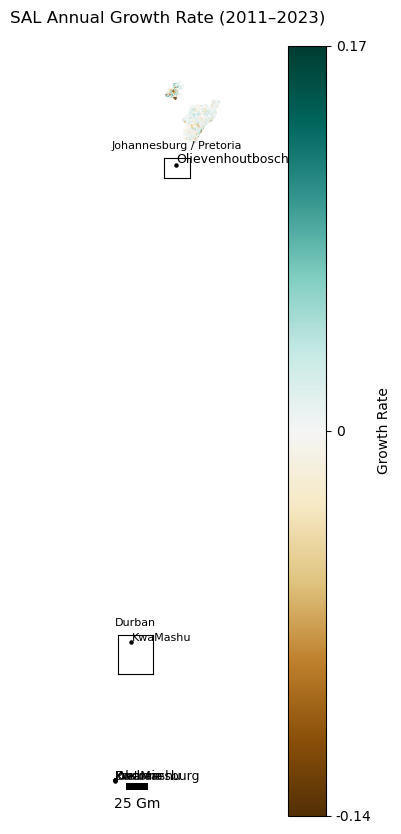

In [74]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
from matplotlib_scalebar.scalebar import ScaleBar

fig, ax = plt.subplots(1, figsize=(16,10))

vmin = sal_map['growth_rate'].min()
vmax = sal_map['growth_rate'].max()

norm = colors.TwoSlopeNorm(
    vmin=vmin,
    vcenter=0,
    vmax=vmax
)

cmap = cm.BrBG
scalebar = ScaleBar(
    dx=111000,
    units="m",
    dimension="si-length",
    location='lower left'
)      
sal_map.plot(
    column='growth_rate',
    cmap=cmap,
    norm=norm,
    legend=False,
    ax=ax
)

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

axins = inset_axes(ax, width="30%", height="30%", bbox_to_anchor=(0, 0, .75, 1), loc="upper right", bbox_transform=ax.transAxes)
sal_map.plot(column='growth_rate', cmap=cmap, norm=norm, legend=False, ax=axins)

axins2 = inset_axes(ax, width="30%", height="30%", loc="lower left",
    bbox_to_anchor=(0.01, 0.05, 1, 1), bbox_transform=ax.transAxes)
sal_map.plot(column='growth_rate', cmap=cmap, norm=norm, legend=False, ax=axins2)

axins.set_xlim(27.75, 28.50)
axins.set_ylim(-26.30, -25.70)
axins.scatter(28.0934, -25.9075, color='black', s=5, zorder=20)
axins.text(28.0934 + 0.02, -25.9075 + 0.05, "Olievenhoutbosch", fontsize=9, ha='left')
axins.set_xticks([])
axins.set_yticks([])
axins.set_title("Johannesburg / Pretoria", fontsize=8)

axins2.set_xlim(30.85, 31.20)
axins2.set_ylim(-30.05, -29.65)
axins2.scatter(30.9849, -29.7280, color='black', s=5, zorder=20)
axins2.text(30.9849 + 0.01, -29.7280 + 0.01, "KwaMashu", fontsize=8, ha='left')
axins2.set_xticks([])
axins2.set_yticks([])
axins2.set_title("Durban", fontsize=8)

sm = cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_ticks([vmin, 0, vmax])
cbar.set_ticklabels([f"{vmin:.2f}", "0", f"{vmax:.2f}"])
cbar.set_label("Growth Rate")

ax.scatter(28.0473, -26.2041, color='black', s=5, zorder=20)
ax.text(28.0473 - 0.08, -26.2041 + 0.05, "Johannesburg", fontsize=9)
ax.scatter(28.2293, -25.7479, color='black', s=5, zorder=20)
ax.text(28.2293 - 0.03, -25.7479 + 0.05, "Pretoria", fontsize=9)
ax.scatter(31.0218, -29.8587, color='black', s=5, zorder=20)
ax.text(31.0218 + 0.02, -29.8587, "Durban", fontsize=9)
ax.scatter(30.9849, -29.7280, color='black', s=5, zorder=20)
ax.text(30.9849 - 0.02, -29.7280 + 0.13, "KwaMashu", fontsize=9)

ax.set_title("SAL Annual Growth Rate (2011–2023)")
ax.set_axis_off()
ax.add_artist(scalebar)

#plt.savefig("visuals/growth_rate_map.png", dpi=300, bbox_inches='tight')
plt.show()

<Axes: >

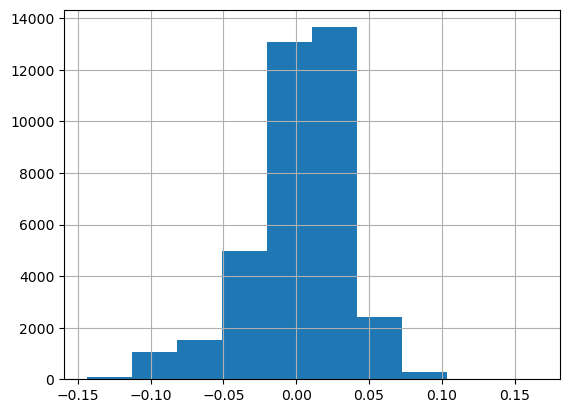

In [73]:
sal_wards['growth_rate'].hist()

In [75]:
print(sal_wards.loc[sal_wards['growth_rate'].idxmin()])

WardID                 74804019
EA_CODE                76610108
sal2011_pop               17.00
ward2023_pop               1444
EA_GTYPE                  Urban
EA_TYPE              Industrial
econ_status     Non_Residential
houses2011               327.00
Black_Afri                    9
White                         8
Coloured                      0
Indian_or                     0
Other                         0
area_km2                   0.63
sal_dense                 26.91
log_density                3.33
ward2011_sum           9,309.90
share2011                  0.00
dasym_weight               0.00
sal2023_est                2.64
growth_rate               -0.14
Name: 5661, dtype: object


In [76]:
sal_wards.loc[sal_wards['sal_dense'].idxmax()]

WardID             59500022
EA_CODE            59913668
sal2011_pop        1,306.00
ward2023_pop          21794
EA_GTYPE              Urban
EA_TYPE            Township
econ_status     Non_Wealthy
houses2011            10.00
Black_Afri             1304
White                     0
Coloured                  2
Indian_or                 0
Other                     0
area_km2               0.00
sal_dense        662,594.71
log_density           13.40
ward2011_sum      32,132.00
share2011              0.04
dasym_weight           0.04
sal2023_est          885.81
growth_rate           -0.03
Name: 19441, dtype: object

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import PathPatch

fig, ax = plt.subplots(figsize=(10, 10))

# --- KDE plot ---
kde = sns.kdeplot(
    x=pop.geometry.x,
    y=pop.geometry.y,
    weights=pop["sal2023_est"].fillna(0),
    fill=True,
    cmap="hot",
    levels=200,
    bw_adjust=0.6,
    thresh=0.01,
    cut=0,
    ax=ax
)

# --- Create a single unified polygon ---
mask_geom = salpoly.unary_union

# Convert to matplotlib patch
patch = PathPatch(
    plt.Polygon(list(mask_geom.exterior.coords)),
    transform=ax.transData
)

# --- Clip ALL contour collections ---
for col in ax.collections:
    col.set_clip_path(patch)

# --- Draw boundary on top ---
salpoly.boundary.plot(ax=ax, color="black", linewidth=1)

# limits
minx, miny, maxx, maxy = salpoly.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

plt.title("Population Heat Map (Clipped to Provinces)")
plt.axis("off")
plt.savefig("heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

In [77]:
sal_with_ward = pd.read_csv("pop_pred_final.csv")

In [78]:
sal_with_ward= sal_with_ward.merge(
    sal, 
    on="EA_CODE", 
   )
sal_with_ward = gpd.GeoDataFrame(
    sal_with_ward,
   geometry="geometry")

C:\Users\Tess\AppData\Local\Temp\ipykernel_110172\2200821685.py:1: UserWarning: You are merging on int and float columns where the float values are not equal to their int representation.
  sal_with_ward= sal_with_ward.merge(


In [80]:
phm=pd.read_csv('../notebooks/data/PHARMACIES_MASTER_FINAL.csv')
pharm_gdf = gpd.GeoDataFrame(
    phm,
    geometry=gpd.points_from_xy(phm['LNG'], phm['LAT']),
    crs="EPSG:4326"  # WGS84
)

<Axes: >

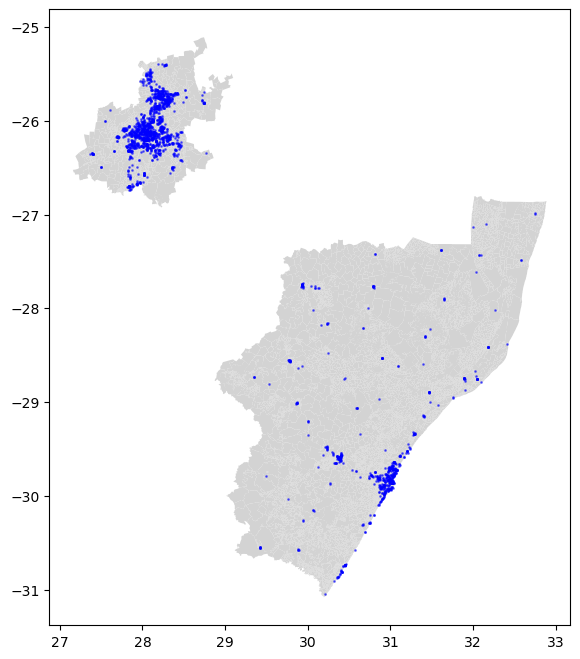

In [81]:
pharm_in_pr = gpd.sjoin(
    pharm_gdf,
    sal,
    predicate='within'
)

fig, ax = plt.subplots(figsize=(8,8))

# plot polygons
sal.plot(
    ax=ax,
    color='lightgrey',     # fill color
    linewidth=0.5
)

# (optional) plot pharmacies on top
pharm_in_pr.plot(
    ax=ax,
    color='blue',
    markersize=1,
    alpha=0.5
)